In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
data = pd.read_csv(r"C:\Users\yaofr\OneDrive\Documents\Projets_Data\AI_impact_on_Job_in_2030\AI_Impact_on_Jobs_2030.csv")

In [3]:
df = data.copy()

In [4]:
print(df[['Education_Level', 'AI_Replacement_Risk']].dtypes)

Education_Level            str
AI_Replacement_Risk    float64
dtype: object


In [5]:
print("\nExemples de valeurs pour AI_Replacement_Risk :")
print(df['AI_Replacement_Risk'].unique()[:5])


Exemples de valeurs pour AI_Replacement_Risk :
[0.25 0.73 0.8  0.29 0.11]


In [6]:
print(df['Education_Level'].unique())

<StringArray>
['PhD', 'Bachelor', 'High School', 'Master']
Length: 4, dtype: str


In [7]:
df.groupby('Education_Level')['AI_Replacement_Risk'].mean()

Education_Level
Bachelor       0.495921
High School    0.505626
Master         0.508624
PhD            0.502169
Name: AI_Replacement_Risk, dtype: float64

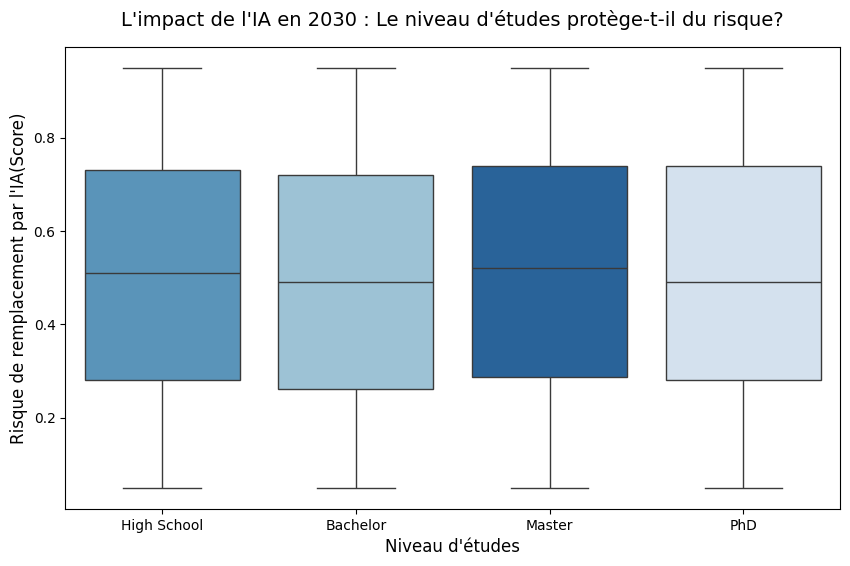

In [8]:
ordres_etudes = ['High School', 'Bachelor', 'Master', 'PhD']

plt.figure(figsize = (10, 6))
sns.boxplot(
    data = df,
    x = 'Education_Level',
    y = 'AI_Replacement_Risk',
    order = ordres_etudes,
    palette= 'Blues',
    hue = 'Education_Level'
)

plt.title("L'impact de l'IA en 2030 : Le niveau d'études protège-t-il du risque?", fontsize = 14, pad = 15)
plt.xlabel("Niveau d'études", fontsize=12)
plt.ylabel("Risque de remplacement par l'IA(Score)", fontsize=12)

plt.show()

In [9]:
df['Required_Skills'].unique()[:5]

<StringArray>
[                                      'Python, Communication, Deep Learning',
           'Deep Learning, Azure, Communication, TensorFlow, PyTorch, Python',
 'Kubernetes, Cloud Computing, TensorFlow, SQL, Communication, Cybersecurity',
                          'Excel, Kubernetes, Prompt Engineering, Leadership',
                                 'SQL, Leadership, TensorFlow, Cybersecurity']
Length: 5, dtype: str

In [10]:
df_skills = df[['AI_Replacement_Risk', 'Required_Skills']].copy()

df_skills['Required_Skills'] = df_skills['Required_Skills'].str.split(', ')

df_skills = df_skills.explode('Required_Skills')

print(df_skills.head(10))

   AI_Replacement_Risk Required_Skills
0                 0.25          Python
0                 0.25   Communication
0                 0.25   Deep Learning
1                 0.73   Deep Learning
1                 0.73           Azure
1                 0.73   Communication
1                 0.73      TensorFlow
1                 0.73         PyTorch
1                 0.73          Python
2                 0.80      Kubernetes


In [11]:
df_skills.groupby('Required_Skills')['AI_Replacement_Risk'].mean()

Required_Skills
AWS                   0.506510
Azure                 0.490065
Cloud Computing       0.500471
Communication         0.503260
Cybersecurity         0.508995
Data Visualization    0.504767
Deep Learning         0.503571
Docker                0.512048
Excel                 0.495811
Kubernetes            0.504587
Leadership            0.505026
Machine Learning      0.505882
Project Management    0.510176
Prompt Engineering    0.506649
PyTorch               0.513306
Python                0.507521
SQL                   0.494458
TensorFlow            0.516942
Name: AI_Replacement_Risk, dtype: float64

**Test de corrélation**

In [12]:
colonnes_num = ['Years_Experience', 'Average_Salary_USD', 'AI_Replacement_Risk', 'Job_Growth_2030', 'Performance_Score']
matrice_corr = df[colonnes_num].corr()
print(matrice_corr)

                     Years_Experience  Average_Salary_USD  \
Years_Experience             1.000000            0.012795   
Average_Salary_USD           0.012795            1.000000   
AI_Replacement_Risk         -0.033668           -0.006714   
Job_Growth_2030             -0.023781           -0.011723   
Performance_Score            0.023758           -0.009519   

                     AI_Replacement_Risk  Job_Growth_2030  Performance_Score  
Years_Experience               -0.033668        -0.023781           0.023758  
Average_Salary_USD             -0.006714        -0.011723          -0.009519  
AI_Replacement_Risk             1.000000         0.004887          -0.012806  
Job_Growth_2030                 0.004887         1.000000          -0.011879  
Performance_Score              -0.012806        -0.011879           1.000000  


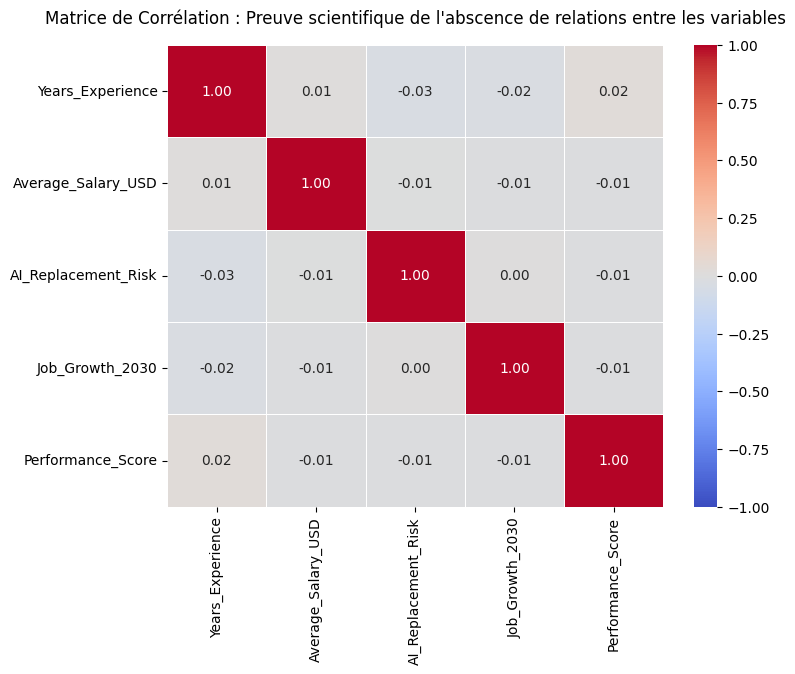

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation : Preuve scientifique de l'abscence de relations entre les variables", fontsize=12, pad=15)
plt.show()